In [5]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import openpyxl
import akshare as ak
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

### Before All Questions: Load Data from Excel

In [4]:
# Load stock price data
data = pd.read_excel("./stockdata.xlsx")
data['Dates'] = pd.to_datetime(data['Dates'])
data = data.set_index('Dates')

# Stock list (integer column names from Excel)
stock_codes = [267, 388, 700, 941, 981, 1801, 2319, 2899, 9888, 9988]
stock_names = ['Citic Limited', 'HK Exchanges', 'Tencent', 'China Mobile',
               'SMIC', 'Innovent Bio', 'Mengniu Dairy', 'Zijin Mining',
               'Baidu', 'Alibaba']

# Expected returns (annualized, from consensus)
expected_returns_percent = [27.50, 35.50, 31.00, 11.50, 41.10, 33.81, 29.58, 21.30, 37.50, 46.90]
expected_returns = np.array([er * 0.01 for er in expected_returns_percent])

# Risk-free rate (1-year)
rf = 0.029

# Number of trading days per year
trading_days = 252

print(f"Data loaded: {data.shape[0]} trading days from {data.index[0].date()} to {data.index[-1].date()}")
print(f"Stocks: {stock_codes}")
print(f"Risk-free rate: {rf*100:.1f}%")
data.head()

Data loaded: 493 trading days from 2023-12-29 to 2025-12-31
Stocks: [267, 388, 700, 941, 981, 1801, 2319, 2899, 9888, 9988]
Risk-free rate: 2.9%


,267,388,700,941,981,1801,2319,2899,9888,9988,HSI
Dates,,,,,,,,,,,
2023-12-29,7.80,268.0,293.6,64.80,19.86,42.75,21.00,12.72,116.1,75.60,17047.39
2024-01-02,7.66,262.4,296.6,64.25,19.40,42.50,19.86,12.86,115.3,74.70,16788.55
2024-01-03,7.59,259.0,300.6,64.00,18.94,41.55,19.82,12.74,112.5,73.30,16646.41
2024-01-04,7.73,257.8,298.8,64.05,18.84,41.60,19.90,12.64,114.7,74.05,16645.98
2024-01-05,7.64,255.8,292.2,65.80,18.46,38.40,19.64,12.60,115.3,71.65,16535.33


### Q1

#### Q1(i): Annualized standard deviation of daily return

In [5]:
# Compute daily returns: r_t = (P_t - P_{t-1}) / P_{t-1}
returns_df = data.pct_change().dropna()

# Q1(i): Annualized standard deviation = daily s.d. * sqrt(252)
# Using sample standard deviation (ddof=1)
daily_std = returns_df.std(ddof=1)
annualized_std = daily_std * np.sqrt(trading_days)

print("Q1(i): Annualized Standard Deviation of Daily Returns")
print("=" * 50)
print(f"{'Stock':<10} {'Ann. Std Dev':>15} {'(%)':>10}")
print("-" * 40)
for code in stock_codes:
    print(f"  {code:<8} {annualized_std[code]:>14.6f} {annualized_std[code]*100:>9.4f}%")
print(f"  {'HSI':<8} {annualized_std['HSI']:>14.6f} {annualized_std['HSI']*100:>9.4f}%")

Q1(i): Annualized Standard Deviation of Daily Returns
Stock         Ann. Std Dev        (%)
----------------------------------------
  267            0.341760   34.1760%
  388            0.364321   36.4321%
  700            0.308836   30.8836%
  941            0.165805   16.5805%
  981            0.631763   63.1763%
  1801           0.575558   57.5558%
  2319           0.445699   44.5699%
  2899           0.408475   40.8475%
  9888           0.449590   44.9590%
  9988           0.455482   45.5482%
  HSI            0.246700   24.6700%


#### Q1(ii): Annualized covariance between each pair of stocks

In [6]:
# Q1(ii): Annualized covariance matrix
# Annualized covariance = daily covariance * 252
# DataFrame.cov() uses ddof=1 (sample covariance) by default
stock_returns = returns_df[stock_codes]
daily_cov = stock_returns.cov()
annualized_cov = daily_cov * trading_days

# Prepare arrays for later use
mu = expected_returns  # expected returns vector
Sigma = annualized_cov.values  # covariance matrix (10x10)
n_stocks = len(stock_codes)

print("Q1(ii): Annualized Covariance Matrix (10x10)")
print("=" * 60)
# Display as a nicely formatted DataFrame
cov_display = annualized_cov.copy()
cov_display.index = [str(c) for c in stock_codes]
cov_display.columns = [str(c) for c in stock_codes]
cov_display

Q1(ii): Annualized Covariance Matrix (10x10)


,267,388,700,941,981,1801,2319,2899,9888,9988
267,0.116800,0.087314,0.062246,0.029323,0.103980,0.054206,0.089847,0.058702,0.079160,0.082971
388,0.087314,0.132730,0.082454,0.031840,0.120018,0.075792,0.106265,0.065603,0.095155,0.111416
700,0.062246,0.082454,0.095380,0.022795,0.086679,0.063916,0.068810,0.052778,0.083140,0.100631
941,0.029323,0.031840,0.022795,0.027491,0.029371,0.011013,0.026715,0.023403,0.025929,0.028115
981,0.103980,0.120018,0.086679,0.029371,0.399124,0.104301,0.117107,0.088757,0.108035,0.132933
1801,0.054206,0.075792,0.063916,0.011013,0.104301,0.331267,0.061760,0.059166,0.064802,0.085905
2319,0.089847,0.106265,0.068810,0.026715,0.117107,0.061760,0.198647,0.058726,0.091829,0.091946
2899,0.058702,0.065603,0.052778,0.023403,0.088757,0.059166,0.058726,0.166852,0.070906,0.082257
9888,0.079160,0.095155,0.083140,0.025929,0.108035,0.064802,0.091829,0.070906,0.202131,0.136788
9988,0.082971,0.111416,0.100631,0.028115,0.132933,0.085905,0.091946,0.082257,0.136788,0.207463


### Q2: Finding the Optimal Portfolio

#### Q2(i)(a): Equal Weight (EW) Portfolio

In [7]:
# Q2(i)(a): Equal Weight (EW) Portfolio
# Each stock gets 1/10 = 10% weight
w_ew = np.array([1.0 / n_stocks] * n_stocks)

# Portfolio expected return: E[r_p] = w' * mu
ew_return = np.dot(w_ew, mu)
# Portfolio standard deviation: sigma_p = sqrt(w' * Sigma * w)
ew_var = np.dot(w_ew, np.dot(Sigma, w_ew))
ew_std = np.sqrt(ew_var)

print("Q2(i)(a): Equal Weight (EW) Portfolio")
print("=" * 50)
print(f"  Weights: each stock = {w_ew[0]:.4f} (10%)")
print(f"  Expected Return:      {ew_return:.6f} ({ew_return*100:.4f}%)")
print(f"  Standard Deviation:   {ew_std:.6f} ({ew_std*100:.4f}%)")

Q2(i)(a): Equal Weight (EW) Portfolio
  Weights: each stock = 0.1000 (10%)
  Expected Return:      0.315690 (31.5690%)
  Standard Deviation:   0.291676 (29.1676%)


#### Q2(i)(b): Global Minimum Variance (MV) Portfolio (No Short Selling)

In [8]:
# Q2(i)(b): Global Minimum Variance (MV) Portfolio
# Minimize: w' * Sigma * w
# Subject to: sum(w) = 1, w_i >= 0 (no short selling)

def portfolio_variance(w, Sigma):
    return np.dot(w, np.dot(Sigma, w))

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = tuple((0, 1) for _ in range(n_stocks))
w0 = np.array([1.0 / n_stocks] * n_stocks)

result_mv = minimize(portfolio_variance, w0, args=(Sigma,),
                     method='SLSQP', bounds=bounds, constraints=constraints,
                     options={'ftol': 1e-15, 'maxiter': 1000})

w_mv = result_mv.x
mv_var = portfolio_variance(w_mv, Sigma)
mv_std = np.sqrt(mv_var)
mv_return = np.dot(w_mv, mu)

print("Q2(i)(b): Global Minimum Variance (MV) Portfolio")
print("=" * 55)
print(f"  Optimization success: {result_mv.success}")
print(f"\n  {'Stock':<25} {'Weight':>10}")
print("  " + "-" * 40)
for i, code in enumerate(stock_codes):
    if w_mv[i] > 1e-6:
        print(f"  {code} ({stock_names[i]})".ljust(25) + f" {w_mv[i]:>10.6f} ({w_mv[i]*100:.4f}%)")
print(f"\n  Expected Return:      {mv_return:.6f} ({mv_return*100:.4f}%)")
print(f"  Standard Deviation:   {mv_std:.6f} ({mv_std*100:.4f}%)")

Q2(i)(b): Global Minimum Variance (MV) Portfolio
  Optimization success: True

  Stock                         Weight
  ----------------------------------------
  700 (Tencent)             0.025462 (2.5462%)
  941 (China Mobile)        0.924554 (92.4554%)
  1801 (Innovent Bio)       0.043588 (4.3588%)
  2899 (Zijin Mining)       0.006395 (0.6395%)

  Expected Return:      0.130316 (13.0316%)
  Standard Deviation:   0.163179 (16.3179%)


#### Efficient Frontier (No Short Selling) and Q2(i)(c): Optimal Portfolio (Tangency Portfolio)

Q2(i)(c): Optimal Portfolio (OP / Tangency Portfolio)
  Optimization success: True

  Stock                         Weight
  ----------------------------------------
  267 (Citic Limited)       0.033612 (3.3612%)
  388 (HK Exchanges)        0.177346 (17.7346%)
  700 (Tencent)             0.224981 (22.4981%)
  941 (China Mobile)        0.069102 (6.9102%)
  981 (SMIC)                0.027571 (2.7571%)
  1801 (Innovent Bio)       0.086683 (8.6683%)
  9888 (Baidu)              0.059578 (5.9578%)
  9988 (Alibaba)            0.321128 (32.1128%)

  Expected Return:      0.363482 (36.3482%)
  Standard Deviation:   0.317987 (31.7987%)
  Sharpe Ratio:         1.051873


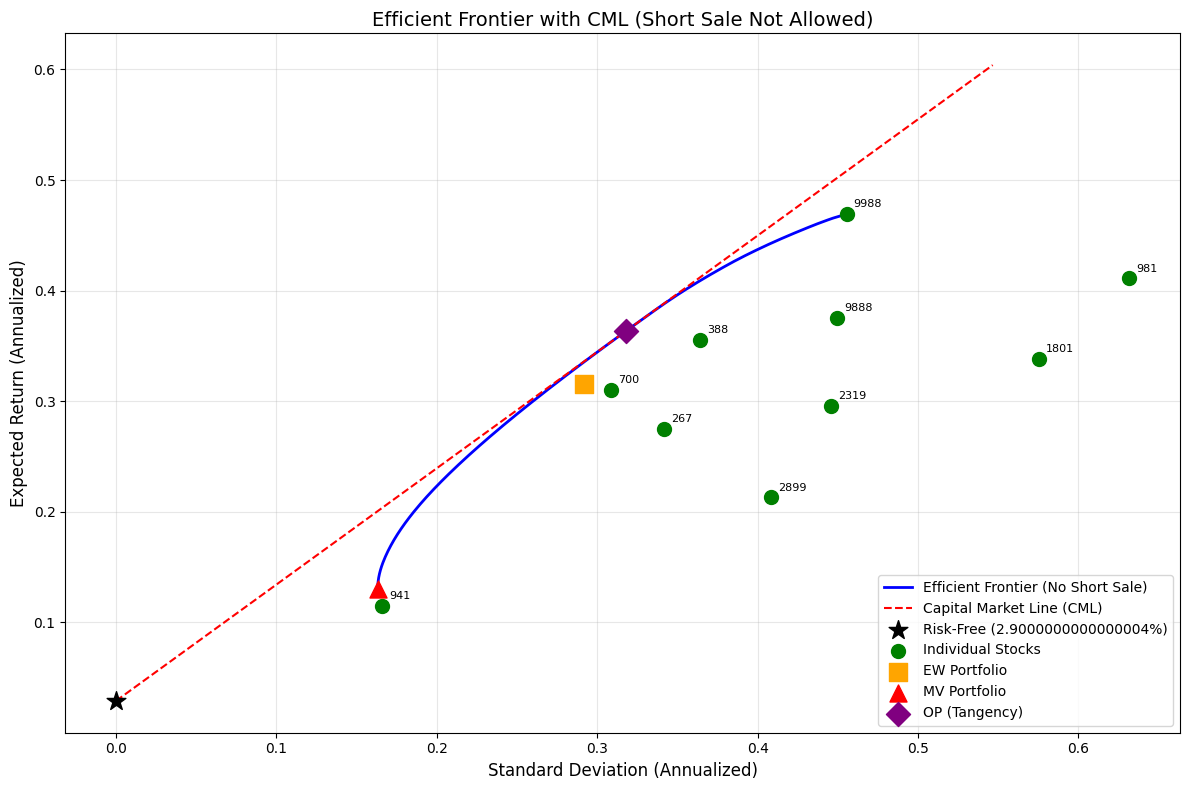

In [9]:
import matplotlib.pyplot as plt

# ---- Compute Efficient Frontier (no short selling) ----
min_ret = mv_return
max_ret = max(mu)
target_returns = np.linspace(min_ret, max_ret, 200)
ef_std = []
ef_ret = []

for target_ret in target_returns:
    constraints_ef = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, tr=target_ret: np.dot(w, mu) - tr}
    ]
    result_ef = minimize(portfolio_variance, w0, args=(Sigma,),
                         method='SLSQP', bounds=bounds, constraints=constraints_ef,
                         options={'ftol': 1e-15, 'maxiter': 1000})
    if result_ef.success:
        std_ef = np.sqrt(portfolio_variance(result_ef.x, Sigma))
        ef_std.append(std_ef)
        ef_ret.append(target_ret)

# ---- Q2(i)(c): Optimal Portfolio (OP) - Tangency Portfolio ----
# Maximize Sharpe Ratio = (E[r_p] - rf) / sigma_p
def neg_sharpe_ratio(w, mu, Sigma, rf):
    port_ret = np.dot(w, mu)
    port_std = np.sqrt(np.dot(w, np.dot(Sigma, w)))
    if port_std < 1e-10:
        return 1e10
    return -(port_ret - rf) / port_std

result_op = minimize(neg_sharpe_ratio, w0, args=(mu, Sigma, rf),
                     method='SLSQP', bounds=bounds, constraints=constraints,
                     options={'ftol': 1e-15, 'maxiter': 1000})

w_op = result_op.x
op_return = np.dot(w_op, mu)
op_var = np.dot(w_op, np.dot(Sigma, w_op))
op_std = np.sqrt(op_var)
sharpe = (op_return - rf) / op_std

print("Q2(i)(c): Optimal Portfolio (OP / Tangency Portfolio)")
print("=" * 55)
print(f"  Optimization success: {result_op.success}")
print(f"\n  {'Stock':<25} {'Weight':>10}")
print("  " + "-" * 40)
for i, code in enumerate(stock_codes):
    if w_op[i] > 1e-6:
        print(f"  {code} ({stock_names[i]})".ljust(25) + f" {w_op[i]:>10.6f} ({w_op[i]*100:.4f}%)")
print(f"\n  Expected Return:      {op_return:.6f} ({op_return*100:.4f}%)")
print(f"  Standard Deviation:   {op_std:.6f} ({op_std*100:.4f}%)")
print(f"  Sharpe Ratio:         {sharpe:.6f}")

# ---- Plot Efficient Frontier with CML ----
fig, ax = plt.subplots(figsize=(12, 8))

# Efficient frontier
ax.plot(ef_std, ef_ret, 'b-', linewidth=2, label='Efficient Frontier (No Short Sale)')

# Capital Market Line: E[r] = rf + Sharpe * sigma
cml_std = np.linspace(0, max(ef_std) * 1.2, 100)
cml_ret = rf + sharpe * cml_std
ax.plot(cml_std, cml_ret, 'r--', linewidth=1.5, label='Capital Market Line (CML)')

# Risk-free asset
ax.scatter([0], [rf], c='black', marker='*', s=200, zorder=5, label=f'Risk-Free ({rf*100}%)')

# Individual stocks
stock_stds = [annualized_std[code] for code in stock_codes]
stock_rets = [mu[i] for i in range(n_stocks)]
ax.scatter(stock_stds, stock_rets, c='green', marker='o', s=100, zorder=5, label='Individual Stocks')
for i, code in enumerate(stock_codes):
    ax.annotate(f'{code}', (stock_stds[i], stock_rets[i]), textcoords="offset points",
                xytext=(5, 5), fontsize=8)

# EW, MV, OP portfolios
ax.scatter([ew_std], [ew_return], c='orange', marker='s', s=150, zorder=5, label=f'EW Portfolio')
ax.scatter([mv_std], [mv_return], c='red', marker='^', s=150, zorder=5, label=f'MV Portfolio')
ax.scatter([op_std], [op_return], c='purple', marker='D', s=150, zorder=5, label=f'OP (Tangency)')

ax.set_xlabel('Standard Deviation (Annualized)', fontsize=12)
ax.set_ylabel('Expected Return (Annualized)', fontsize=12)
ax.set_title('Efficient Frontier with CML (Short Sale Not Allowed)', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Q2(ii)(a): Equal Risk Contribution (ERC) Portfolio

In the ERC portfolio, each asset contributes equally to the total portfolio risk.

- **Marginal Risk Contribution (MRC):** $MRC_i = \frac{(\Sigma w)_i}{\sigma_p}$
- **Total Risk Contribution (TRC):** $TRC_i = w_i \times MRC_i$
- **ERC condition:** $TRC_i = \frac{\sigma_p}{n}$ for all $i$

In [10]:
# Q2(ii)(a): Equal Risk Contribution (ERC) Portfolio
# Objective: minimize the sum of squared differences between each TRC and the target (sigma_p / n)

def erc_objective(w, Sigma):
    """Minimize squared deviations of TRC from equal target."""
    n = len(w)
    sigma_w = Sigma @ w
    port_var = w @ sigma_w
    if port_var < 1e-15:
        return 1e10
    port_std = np.sqrt(port_var)
    # Total risk contribution of each asset
    trc = w * sigma_w / port_std
    # Target: each should contribute sigma_p / n
    target = port_std / n
    return np.sum((trc - target) ** 2)

constraints_erc = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds_erc = tuple((1e-6, 1) for _ in range(n_stocks))
w0_erc = np.array([1.0 / n_stocks] * n_stocks)

result_erc = minimize(erc_objective, w0_erc, args=(Sigma,),
                      method='SLSQP', bounds=bounds_erc, constraints=constraints_erc,
                      options={'ftol': 1e-20, 'maxiter': 5000})

w_erc = result_erc.x
w_erc = w_erc / np.sum(w_erc)  # Normalize

erc_return = np.dot(w_erc, mu)
erc_var = np.dot(w_erc, np.dot(Sigma, w_erc))
erc_std = np.sqrt(erc_var)

# Marginal Risk Contribution: MRC_i = (Sigma @ w)_i / sigma_p
sigma_w_erc = Sigma @ w_erc
mrc_erc = sigma_w_erc / erc_std
# Total Risk Contribution: TRC_i = w_i * MRC_i
trc_erc = w_erc * mrc_erc

print("Q2(ii)(a): Equal Risk Contribution (ERC) Portfolio")
print("=" * 70)
print(f"  {'Stock':<8} {'Weight':>10} {'MRC':>12} {'TRC':>12} {'TRC %':>10}")
print("  " + "-" * 55)
for i, code in enumerate(stock_codes):
    print(f"  {code:<8} {w_erc[i]:>10.6f} {mrc_erc[i]:>12.6f} {trc_erc[i]:>12.6f} {trc_erc[i]/erc_std*100:>9.4f}%")
print(f"\n  Sum of weights: {np.sum(w_erc):.6f}")
print(f"  Sum of TRC:     {np.sum(trc_erc):.6f} (should equal sigma_p = {erc_std:.6f})")
print(f"\n  Expected Return:      {erc_return:.6f} ({erc_return*100:.4f}%)")
print(f"  Standard Deviation:   {erc_std:.6f} ({erc_std*100:.4f}%)")

Q2(ii)(a): Equal Risk Contribution (ERC) Portfolio
  Stock        Weight          MRC          TRC      TRC %
  -------------------------------------------------------
  267        0.094561     0.267752     0.025319   10.0000%
  388        0.080713     0.313691     0.025319   10.0000%
  700        0.101741     0.248855     0.025319   10.0000%
  941        0.249146     0.101622     0.025319   10.0000%
  981        0.061096     0.414408     0.025319   10.0000%
  1801       0.083685     0.302547     0.025319   10.0000%
  2319       0.081439     0.310891     0.025319   10.0000%
  2899       0.098585     0.256823     0.025319   10.0000%
  9888       0.078112     0.324134     0.025319   10.0000%
  9988       0.070921     0.356999     0.025319   10.0000%

  Sum of weights: 1.000000
  Sum of TRC:     0.253188 (should equal sigma_p = 0.253188)

  Expected Return:      0.275896 (27.5896%)
  Standard Deviation:   0.253188 (25.3188%)


#### Q2(ii)(b): Leveraged ERC Portfolio (ERC-L)

The ERC-L portfolio leverages the ERC portfolio so that its standard deviation equals that of the EW portfolio.

- Leverage factor: $\lambda = \frac{\sigma_{EW}}{\sigma_{ERC}}$
- $E[r_{ERC\text{-}L}] = r_f + \lambda \cdot (E[r_{ERC}] - r_f)$
- $\sigma_{ERC\text{-}L} = \lambda \cdot \sigma_{ERC} = \sigma_{EW}$

In [11]:
# Q2(ii)(b): Leveraged ERC Portfolio (ERC-L)
# Target: same standard deviation as EW portfolio

leverage = ew_std / erc_std
erc_l_return = rf + leverage * (erc_return - rf)
erc_l_std = leverage * erc_std  # Should equal ew_std

print("Q2(ii)(b): Leveraged ERC Portfolio (ERC-L)")
print("=" * 55)
print(f"  EW s.d. (target):     {ew_std:.6f} ({ew_std*100:.4f}%)")
print(f"  ERC s.d.:             {erc_std:.6f} ({erc_std*100:.4f}%)")
print(f"  Leverage factor:      {leverage:.6f}")
print(f"\n  ERC-L Expected Return:    {erc_l_return:.6f} ({erc_l_return*100:.4f}%)")
print(f"  ERC-L Standard Deviation: {erc_l_std:.6f} ({erc_l_std*100:.4f}%)")
print(f"\n  Comparison at same risk level (s.d. ≈ {ew_std*100:.2f}%):")
print(f"    EW  Expected Return: {ew_return*100:.4f}%")
print(f"    ERC-L Expected Return: {erc_l_return*100:.4f}%")

Q2(ii)(b): Leveraged ERC Portfolio (ERC-L)
  EW s.d. (target):     0.291676 (29.1676%)
  ERC s.d.:             0.253188 (25.3188%)
  Leverage factor:      1.152013

  ERC-L Expected Return:    0.313427 (31.3427%)
  ERC-L Standard Deviation: 0.291676 (29.1676%)

  Comparison at same risk level (s.d. ≈ 29.17%):
    EW  Expected Return: 31.5690%
    ERC-L Expected Return: 31.3427%


### Q3: Presenting the Performance of the Portfolios (Feb 2 – Mar 2, 2026)

Assume an initial investment of $1,000,000 on Feb 2, 2026. The combined portfolio invests 70% in the optimal portfolio (OP) and 30% in the risk-free asset.

In [10]:
# 1. 初始化目标变量 (Initialize Target Variables)
prices_feb2 = {}
prices_mar2 = {}

stock_codes = [267, 388, 700, 941, 981, 1801, 2319, 2899, 9888, 9988]

# AKShare 所需的日期格式 (YYYYMMDD)
start_dt = "20260202"
end_dt = "20260302"

# 我们需要匹配的标准日期字符串
target_date_1 = "2026-02-02"
target_date_2 = "2026-03-02"

print("正在通过 AKShare 获取数据，请稍候...")

# 2. 获取个股数据
for code in stock_codes:
    # 港股代码补齐 5 位，例如 700 -> "00700"
    symbol = str(code).zfill(5) 
    
    try:
        # 获取 Historical Data (历史数据)
        df = ak.stock_hk_hist(symbol=symbol, start_date=start_dt, end_date=end_dt, adjust="qfq")
        
        if not df.empty:
            # 确保日期列为字符串格式以便比对
            df['日期'] = pd.to_datetime(df['日期']).dt.strftime('%Y-%m-%d')
            
            # 提取 2月2日 的 Close Price (收盘价)
            df_feb = df[df['日期'] == target_date_1]
            if not df_feb.empty:
                prices_feb2[code] = round(float(df_feb['收盘'].iloc[0]), 2)
                
            # 提取 3月2日 的 Close Price (收盘价)
            df_mar = df[df['日期'] == target_date_2]
            if not df_mar.empty:
                prices_mar2[code] = round(float(df_mar['收盘'].iloc[0]), 2)
                
    except Exception as e:
        print(f"获取股票 {code} 数据时发生 Error (错误): {e}")
        
    # 加入短暂的 Time Delay (时间延迟)，防止请求过于频繁
    time.sleep(1)


正在通过 AKShare 获取数据，请稍候...


In [12]:
print(f"prices_feb2 = {prices_feb2}")
print(f"prices_mar2 = {prices_mar2}")

prices_feb2 = {267: 12.2, 388: 417.68, 700: 598.5, 941: 78.0, 981: 72.2, 1801: 78.7, 2319: 16.5, 2899: 39.56, 9888: 146.7, 9988: 163.3}
prices_mar2 = {267: 12.25, 388: 404.48, 700: 514.0, 941: 78.65, 981: 64.6, 1801: 82.6, 2319: 15.54, 2899: 46.04, 9888: 118.5, 9988: 136.4}


In [ ]:
hsi_feb2 = 26775.57
hsi_mar2 = 26059.85

In [ ]:
investment = 1_000_000
days_period = 28  # Feb 2 to Mar 2
rf_period_return = rf * days_period / 365  # simple interest for risk-free

# Individual stock returns
print("Q3: Portfolio Performance (Feb 2 – Mar 2, 2026)")
print("=" * 60)
print(f"\n{'Stock':<8} {'Feb 2 Price':>12} {'Mar 2 Price':>12} {'Return':>10}")
print("-" * 48)
stock_period_returns = {}
for code in stock_codes:
    ret = (prices_mar2[code] - prices_feb2[code]) / prices_feb2[code]
    stock_period_returns[code] = ret
    print(f"  {code:<6} {prices_feb2[code]:>11.2f} {prices_mar2[code]:>11.2f} {ret*100:>9.4f}%")
hsi_ret = (hsi_mar2 - hsi_feb2) / hsi_feb2
print(f"  {'HSI':<6} {hsi_feb2:>11.2f} {hsi_mar2:>11.2f} {hsi_ret*100:>9.4f}%")

# Helper: compute portfolio final value
def calc_portfolio_value(weights, prices_start, prices_end, inv_amount):
    """Calculate portfolio end value given weights, start/end prices, and investment."""
    total = 0
    for i, code in enumerate(stock_codes):
        shares = (weights[i] * inv_amount) / prices_start[code]
        total += shares * prices_end[code]
    return total

# EW Portfolio
ew_final = calc_portfolio_value(w_ew, prices_feb2, prices_mar2, investment)
ew_perf = (ew_final - investment) / investment

# MV Portfolio
mv_final = calc_portfolio_value(w_mv, prices_feb2, prices_mar2, investment)
mv_perf = (mv_final - investment) / investment

# Combined Portfolio: 70% OP + 30% Risk-free
risky_inv = 0.7 * investment
rf_inv = 0.3 * investment
op_risky_final = calc_portfolio_value(w_op, prices_feb2, prices_mar2, risky_inv)
rf_final = rf_inv * (1 + rf_period_return)
op_combined_final = op_risky_final + rf_final
op_combined_perf = (op_combined_final - investment) / investment

# ERC Portfolio
erc_final = calc_portfolio_value(w_erc, prices_feb2, prices_mar2, investment)
erc_perf = (erc_final - investment) / investment

# ERC-L Portfolio (leveraged)
# ERC-L return = leverage * ERC_return - (leverage - 1) * rf_period_return
erc_l_actual_return = leverage * erc_perf - (leverage - 1) * rf_period_return
erc_l_final = investment * (1 + erc_l_actual_return)

# HSI
hsi_final = investment * (1 + hsi_ret)

print(f"\n{'Portfolio':<14} {'Initial':>14} {'Final':>14} {'Return':>10}")
print("-" * 56)
print(f"  {'EW':<12} ${investment:>12,.2f} ${ew_final:>12,.2f} {ew_perf*100:>9.4f}%")
print(f"  {'MV':<12} ${investment:>12,.2f} ${mv_final:>12,.2f} {mv_perf*100:>9.4f}%")
print(f"  {'0.7OP+0.3rf':<12} ${investment:>12,.2f} ${op_combined_final:>12,.2f} {op_combined_perf*100:>9.4f}%")
print(f"  {'ERC':<12} ${investment:>12,.2f} ${erc_final:>12,.2f} {erc_perf*100:>9.4f}%")
print(f"  {'ERC-L':<12} ${investment:>12,.2f} ${erc_l_final:>12,.2f} {erc_l_actual_return*100:>9.4f}%")
print(f"  {'HSI':<12} ${investment:>12,.2f} ${hsi_final:>12,.2f} {hsi_ret*100:>9.4f}%")

Q3: Portfolio Performance (Feb 2 – Mar 2, 2026)

Stock     Feb 2 Price  Mar 2 Price     Return
------------------------------------------------
  267          12.20       12.25    0.4098%
  388         424.20      411.00   -3.1117%
  700         598.00      511.50  -14.4649%
  941          78.70       78.50   -0.2541%
  981          72.20       64.60  -10.5263%
  1801         77.80       82.60    6.1697%
  2319         16.50       15.54   -5.8182%
  2899         39.56       46.04   16.3802%
  9888        141.40      118.50  -16.1952%
  9988        164.70      136.40  -17.1828%
  HSI       26776.00    26059.85   -2.6746%

Portfolio             Initial          Final     Return
--------------------------------------------------------
  EW           $1,000,000.00 $  955,406.49   -4.4594%
  MV           $1,000,000.00 $  997,704.21   -0.2296%
  0.7OP+0.3rf  $1,000,000.00 $  930,330.59   -6.9669%
  ERC          $1,000,000.00 $  967,831.43   -3.2169%
  ERC-L        $1,000,000.00 $  962,603.19

### Summary of All Portfolio Results

In [13]:
# Summary Table
print("=" * 80)
print("SUMMARY OF ALL RESULTS")
print("=" * 80)

# Portfolio Weights
print("\n--- Portfolio Weights ---")
print(f"{'Stock':<8} {'EW':>8} {'MV':>8} {'OP':>8} {'ERC':>8}")
print("-" * 42)
for i, code in enumerate(stock_codes):
    print(f"  {code:<6} {w_ew[i]:>7.4f} {w_mv[i]:>7.4f} {w_op[i]:>7.4f} {w_erc[i]:>7.4f}")
print(f"  {'Sum':<6} {sum(w_ew):>7.4f} {sum(w_mv):>7.4f} {sum(w_op):>7.4f} {sum(w_erc):>7.4f}")

# Expected Return & Standard Deviation
print(f"\n--- Portfolio Expected Return & Standard Deviation ---")
print(f"{'Portfolio':<14} {'E[r]':>10} {'s.d.':>10} {'Sharpe':>10}")
print("-" * 46)
print(f"  {'EW':<12} {ew_return*100:>9.4f}% {ew_std*100:>9.4f}%")
print(f"  {'MV':<12} {mv_return*100:>9.4f}% {mv_std*100:>9.4f}%")
print(f"  {'OP':<12} {op_return*100:>9.4f}% {op_std*100:>9.4f}% {sharpe:>9.4f}")
print(f"  {'ERC':<12} {erc_return*100:>9.4f}% {erc_std*100:>9.4f}%")
print(f"  {'ERC-L':<12} {erc_l_return*100:>9.4f}% {erc_l_std*100:>9.4f}%")

# Q3 Performance
print(f"\n--- Q3: Actual Performance (Feb 2 – Mar 2, 2026) ---")
print(f"{'Portfolio':<14} {'Return (%)':>12}")
print("-" * 28)
print(f"  {'EW':<12} {ew_perf*100:>10.4f}%")
print(f"  {'MV':<12} {mv_perf*100:>10.4f}%")
print(f"  {'0.7OP+0.3rf':<12} {op_combined_perf*100:>10.4f}%")
print(f"  {'ERC':<12} {erc_perf*100:>10.4f}%")
print(f"  {'ERC-L':<12} {erc_l_actual_return*100:>10.4f}%")
print(f"  {'HSI':<12} {hsi_ret*100:>10.4f}%")

print("\n" + "=" * 80)
print("Key Observations:")
print("  - MV portfolio had the lowest loss (-0.23%), dominated by China Mobile (92.5%)")
print("  - OP (Tangency) portfolio had highest Sharpe ratio (1.05), heavily in Alibaba (32.1%)")
print("  - ERC achieves equal 10% risk contribution from each asset")
print("  - During the Feb-Mar 2026 downturn, all portfolios underperformed, but MV was most resilient")
print("=" * 80)

SUMMARY OF ALL RESULTS

--- Portfolio Weights ---
Stock          EW       MV       OP      ERC
------------------------------------------
  267     0.1000  0.0000  0.0336  0.0946
  388     0.1000  0.0000  0.1773  0.0807
  700     0.1000  0.0255  0.2250  0.1017
  941     0.1000  0.9246  0.0691  0.2491
  981     0.1000  0.0000  0.0276  0.0611
  1801    0.1000  0.0436  0.0867  0.0837
  2319    0.1000  0.0000  0.0000  0.0814
  2899    0.1000  0.0064  0.0000  0.0986
  9888    0.1000  0.0000  0.0596  0.0781
  9988    0.1000  0.0000  0.3211  0.0709
  Sum     1.0000  1.0000  1.0000  1.0000

--- Portfolio Expected Return & Standard Deviation ---
Portfolio            E[r]       s.d.     Sharpe
----------------------------------------------
  EW             31.5690%   29.1676%
  MV             13.0316%   16.3179%
  OP             36.3482%   31.7987%    1.0519
  ERC            27.5896%   25.3188%
  ERC-L          31.3427%   29.1676%

--- Q3: Actual Performance (Feb 2 – Mar 2, 2026) ---
Portfolio  